# 02 — Model explanations (SHAP)

Three questions:
1. **Globally**, what drives the deployed LightGBM model? Does it lean on the age proxies?
2. **Per application**, can we produce the explanation the model card promises for reviewers and applicants (GDPR Art. 22)?
3. Does the model treat the 50+ group differently *through* the proxies, now that `customer_age` is withheld?

Uses the deployed bundle in `models/model.joblib` (v0.2, no `customer_age`) and the production-months slice.

In [1]:
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap

from fraud_monitor import config
from fraud_monitor.features import split_xy

BLUE, ORANGE = "#2a78d6", "#eb6834"
warnings.filterwarnings("ignore", category=UserWarning, module="shap")
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False, "axes.titleweight": "bold"})

bundle = joblib.load(config.MODEL_PATH)
model, feats, thr = bundle["model"], bundle["features"], bundle["threshold"]
prod = pd.read_parquet(config.APP_PARQUET)
for c in config.CATEGORICAL:
    prod[c] = prod[c].astype("category")
X, y = split_xy(prod)
X = X[feats]
print(f"model: {bundle['name']}, threshold {thr:.4f}, {len(X):,} production applications, {len(feats)} features")

model: lgbm, threshold 0.7149, 205,011 production applications, 33 features


In [2]:
# TreeExplainer is exact for LightGBM; a 20k stratified sample is plenty for global patterns.
rng = np.random.default_rng(0)
idx = np.concatenate([rng.choice(np.where(y == 1)[0], 2000, replace=False), rng.choice(np.where(y == 0)[0], 18000, replace=False)])
Xs, ys = X.iloc[idx], y.iloc[idx]
explainer = shap.TreeExplainer(model)
sv = explainer.shap_values(Xs)
sv = sv[1] if isinstance(sv, list) else sv   # older shap returns [neg, pos]
sv.shape

(20000, 33)

## 1. Global importance

device_os                 0.525
prev_address_months       0.445
housing_status            0.416
phone_home_valid          0.370
has_other_cards           0.366
name_email_similarity     0.326
current_address_months    0.322
email_is_free             0.310
keep_alive_session        0.308
velocity_4w               0.280
dtype: float64

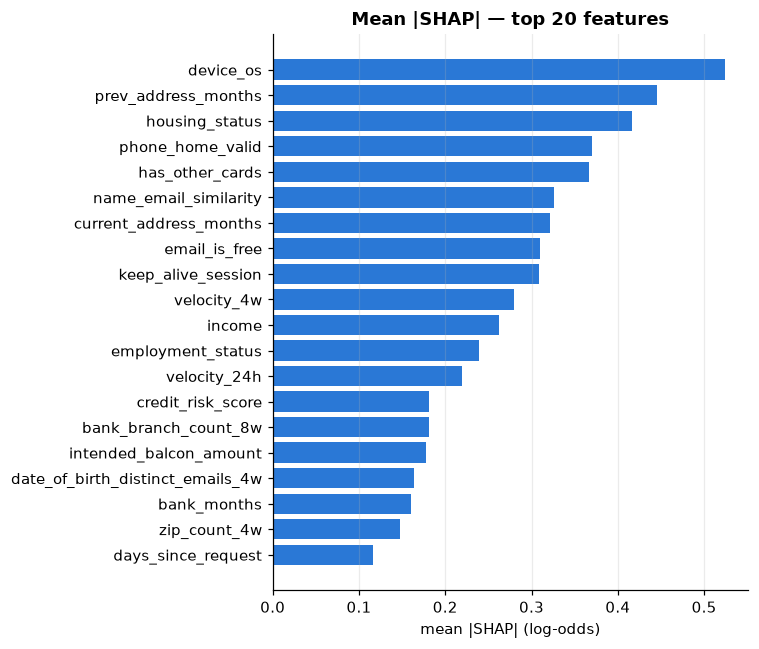

In [3]:
imp = pd.Series(np.abs(sv).mean(0), index=feats).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(7, 6))
ax.barh(imp.index[-20:], imp.values[-20:], color=BLUE)
ax.set(title="Mean |SHAP| — top 20 features", xlabel="mean |SHAP| (log-odds)")
ax.grid(axis="x", alpha=.25)
plt.tight_layout()
imp.sort_values(ascending=False).head(10).round(3)

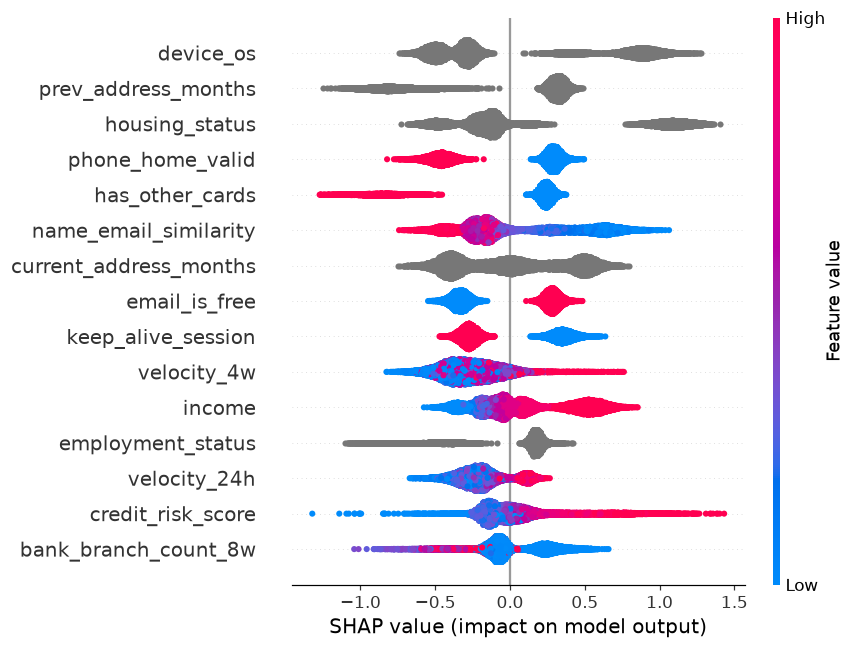

In [4]:
shap.summary_plot(sv, Xs, max_display=15, show=False)
plt.gcf().set_size_inches(8, 6); plt.tight_layout()

**Reading the plots.** The beeswarm shows *direction* as well as magnitude: for each feature, red points
(high values) sitting right of zero mean high values push toward fraud; grey rows are categoricals or
features with missing values, where colour doesn't apply.

The model leans most on **identity and history signals**, not on financial ones: `device_os` and
`housing_status` (the two strongest categoricals in the EDA's chi-square tests), missing previous-address
history (`prev_address_months`), and the verification flags — a valid home phone, existing cards with the bank
and a kept-alive session all push toward *legitimate*; a free email domain and a low `name_email_similarity`
push toward *fraud*. `income` and `credit_risk_score` appear further down with high values pushing toward fraud,
matching the "fraud looks creditworthy" pattern from the EDA.

## 2. Are the age proxies doing age's job?

In [5]:
proxies = ["income", "proposed_credit_limit", "credit_risk_score", "housing_status", "employment_status"]
print("share of total |SHAP| carried by age proxies:", f"{imp[proxies].sum() / imp.sum():.1%}")

# mean SHAP contribution of each proxy, by age group — if the proxies push the 50+ group toward fraud on
# average, the model is reconstructing age from them.
age_grp = np.where(prod.iloc[idx][config.PROTECTED_ATTR] >= config.PROTECTED_THRESHOLD, "50+", "under 50")
contrib = pd.DataFrame(sv, columns=feats).assign(group=age_grp).groupby("group")[proxies].mean().T
contrib["gap (50+ minus under 50)"] = contrib["50+"] - contrib["under 50"]
contrib.round(3)

share of total |SHAP| carried by age proxies: 19.3%


group,50+,under 50,gap (50+ minus under 50)
income,0.139,0.088,0.051
proposed_credit_limit,0.036,-0.002,0.038
credit_risk_score,0.114,0.032,0.082
housing_status,0.278,0.055,0.223
employment_status,0.063,0.046,0.017


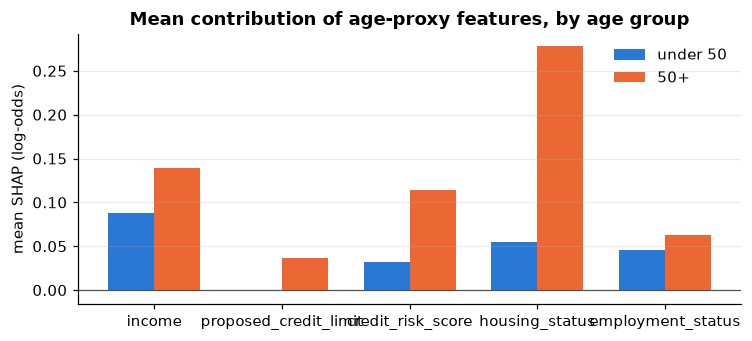

In [6]:
fig, ax = plt.subplots(figsize=(7, 3.2))
pos = np.arange(len(proxies))
ax.bar(pos - .18, contrib["under 50"], width=.36, color=BLUE, label="under 50")
ax.bar(pos + .18, contrib["50+"], width=.36, color=ORANGE, label="50+")
ax.axhline(0, color="#52514e", lw=.8)
ax.set(xticks=pos, xticklabels=proxies, ylabel="mean SHAP (log-odds)", title="Mean contribution of age-proxy features, by age group")
ax.legend(frameon=False); ax.grid(axis="y", alpha=.25)
plt.tight_layout()

**Takeaway.** The five proxies carry about a fifth of the model's total attribution, and every one of them
contributes more toward "fraud" for the 50+ group than for under-50s — `housing_status` most of all
(+0.22 log-odds gap), then `credit_risk_score` (+0.08) and `income` (+0.05). The model has no access to age, yet
these features push older applicants' scores up on average. That is the mechanism behind the residual 2.5×
false-positive gap in the model card: removing age was necessary, but the proxies are where the remaining
disparity lives, and any next step (proxy removal, constrained training) has to address them directly.

## 3. One application, explained

In [7]:
# Pick a *legitimate* 50+ application that the model wrongly holds — the case a reviewer or applicant would ask about.
held = (model.predict_proba(X)[:, 1] >= thr)
cand = np.where(held & (y.values == 0) & (prod[config.PROTECTED_ATTR].values >= 50))[0]
i = int(cand[0])
x_one = X.iloc[[i]]
sv_one = explainer.shap_values(x_one)
sv_one = (sv_one[1] if isinstance(sv_one, list) else sv_one)[0]
base = explainer.expected_value[1] if isinstance(explainer.expected_value, (list, np.ndarray)) else explainer.expected_value
score = model.predict_proba(x_one)[0, 1]
print(f"application #{i}: score {score:.3f} (threshold {thr:.3f}) — held for review; true label: legitimate")

top = pd.Series(sv_one, index=feats).sort_values(key=np.abs, ascending=False).head(8)
expl = pd.DataFrame({"value": x_one.iloc[0][top.index].values, "contribution (log-odds)": top.values}, index=top.index)
expl["direction"] = np.where(expl["contribution (log-odds)"] > 0, "→ fraud", "→ legitimate")
expl.round(3)

application #60: score 0.962 (threshold 0.715) — held for review; true label: legitimate


,value,contribution (log-odds),direction
housing_status,BA,0.949,→ fraud
device_os,windows,0.741,→ fraud
date_of_birth_distinct_emails_4w,2,0.694,→ fraud
name_email_similarity,0.138771,0.578,→ fraud
income,0.9,0.414,→ fraud
prev_address_months,<NA>,0.318,→ fraud
email_is_free,1,0.267,→ fraud
keep_alive_session,1,-0.238,→ legitimate


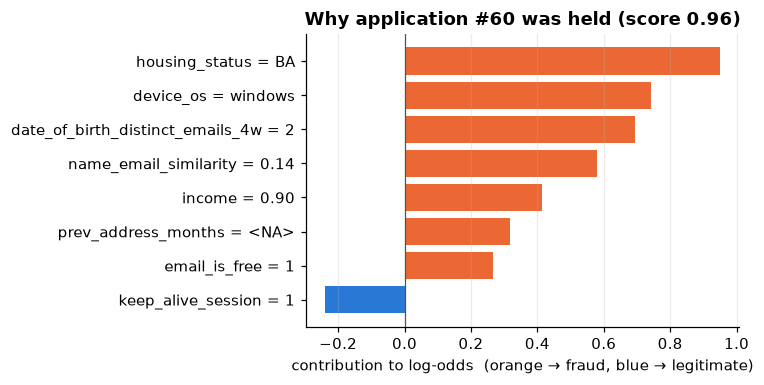

In [8]:
fig, ax = plt.subplots(figsize=(7, 3.6))
colors = [ORANGE if v > 0 else BLUE for v in top.values[::-1]]
ax.barh([f"{f} = {x_one.iloc[0][f]}" if not isinstance(x_one.iloc[0][f], float) else f"{f} = {x_one.iloc[0][f]:.2f}" for f in top.index[::-1]],
        top.values[::-1], color=colors)
ax.axvline(0, color="#52514e", lw=.8)
ax.set(title=f"Why application #{i} was held (score {score:.2f})", xlabel="contribution to log-odds  (orange → fraud, blue → legitimate)")
ax.grid(axis="x", alpha=.25)
plt.tight_layout()

**How this is used.** This is the explanation surface the model card commits to: a reviewer sees the eight
factors that moved the score most, in the applicant's own values, and can judge whether they make sense
(here: an email that doesn't resemble the applicant's name, a free email domain, and no previous-address history — a pattern worth a phone call, not a decline).
The same table can be given to the applicant on request. The model never auto-declines; a human always makes the
final call on held applications.